In [37]:
import numpy as np, pandas as pd, tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/content/drive/MyDrive/AI/week9/TSLA.csv')
data = df['Open'].values.reshape(-1,1)
print("데이터 형상:", df.shape)

데이터 형상: (2956, 7)


In [38]:
# 2. 정규화
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [39]:
# 3-1. train/test 분리
TEST_SIZE = 2400
train_data = data[:-TEST_SIZE]
test = data[-TEST_SIZE:]

In [40]:
# 3-2. SimpleRNN용 데이터셋 생성 (window = 300)
window_rnn = 300

def make_sample(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

X_train_rnn, y_train_rnn = make_sample(train_data, window_rnn)
X_test_rnn, y_test_rnn = make_sample(test, window_rnn)

In [41]:
# 3-3. SimpleRNN 모델 정의
model_rnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(window_rnn, 1)),
    tf.keras.layers.SimpleRNN(
        128,
        return_sequences=True
    ),
    tf.keras.layers.SimpleRNN(
        64,
        return_sequences=True
    ),
    tf.keras.layers.SimpleRNN(
        32,
        return_sequences=True
    ),
    tf.keras.layers.SimpleRNN(
        16
    ),
    tf.keras.layers.Dense(1)
])
model_rnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_12 (SimpleRNN)       │ (None, 300, 128)       │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ (None, 300, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_14 (SimpleRNN)       │ (None, 300, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_15 (SimpleRNN)       │ (None, 16)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,897 (128.50 KB)

 Trainable params: 32,897 (128.50 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# 3-4. SimpleRNN 컴파일 및 학습
model_rnn.compile(
    optimizer='adam',
    loss='mean_squared_error'
)
model_rnn.fit(X_train_rnn, y_train_rnn, epochs=100, batch_size=16)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 194ms/step - loss: 0.2565
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - loss: 0.0068
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 274ms/step - loss: 0.0015
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - loss: 1.7250e-04
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - loss: 5.1846e-05
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 226ms/step - loss: 8.0522e-06
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - loss: 2.1670e-06
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - loss: 4.9417e-07
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 345ms/step - loss: 3.2755e-07
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - loss: 2.7357e-07
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - loss: 2.6612e-07
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - loss: 2.7144e-07
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 269ms/step - loss: 2.8770e-07
Epoch 14/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step - loss: 2.7655e-07

In [43]:
# 3-5. SimpleRNN 예측
pred_rnn = model_rnn.predict(X_test_rnn)

66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step


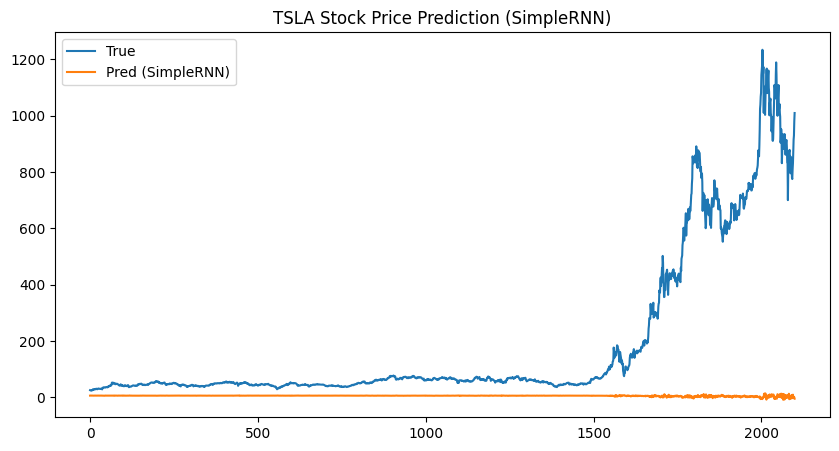

In [44]:
# 3-6. SimpleRNN 예측 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(scaler.inverse_transform(y_test_rnn.reshape(-1, 1)), label='True')
plt.plot(scaler.inverse_transform(pred_rnn.reshape(-1, 1)), label='Pred (SimpleRNN)')
plt.legend()
plt.title("TSLA Stock Price Prediction (SimpleRNN)")
plt.show()

In [45]:
# 4-1. LSTM용 데이터셋 생성 및 분할 (window = 12)
window_lstm = 12

X_lstm, y_lstm = [], []
for i in range(len(data) - window_lstm):
    X_lstm.append(data[i : i + window_lstm])
    y_lstm.append(data[i + window_lstm])
X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

X_train_lstm, y_train_lstm = X_lstm[:-TEST_SIZE], y_lstm[:-TEST_SIZE]
X_test_lstm, y_test_lstm = X_lstm[-TEST_SIZE:], y_lstm[-TEST_SIZE:]

In [46]:
# 4-2. LSTM 모델 구성 및 요약
model_lstm = tf.keras.Sequential()
model_lstm.add(tf.keras.layers.Input(shape=(window_lstm, 1)))
model_lstm.add(tf.keras.layers.LSTM(32, return_sequences=False))
model_lstm.add(tf.keras.layers.Dropout(0.2))
model_lstm.add(tf.keras.layers.Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# 4-3. LSTM 모델 학습
history_lstm = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 2.8495e-06 - val_loss: 4.9246e-07
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.7261e-07 - val_loss: 8.3804e-07
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.2160e-07 - val_loss: 3.1967e-07
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.5122e-07 - val_loss: 5.7127e-07
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.8563e-07 - val_loss: 4.2553e-07
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.0141e-07 - val_loss: 7.6667e-08
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.9499e-07 - val_loss: 2.9361e-07
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.1098e-07 - val_loss: 1.4193e-07
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.9902e-07 - val_loss: 7.6651e-08
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.7015e-07 - val_loss: 9.0190e-08
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.9951e-07 - val_lo

In [48]:
# 4-4. LSTM 예측
pred_lstm = model_lstm.predict(X_test_lstm)

# 역정규화
original_predictions_lstm = scaler.inverse_transform(pred_lstm.reshape(-1, 1))
original_y_test_lstm = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

print("\n" + "="*40)
print("첫 번째 테스트 데이터 예측 주가 ($) [LSTM]:", original_predictions_lstm[0][0])
print("첫 번째 테스트 데이터 실제 주가 ($) [LSTM]:", original_y_test_lstm[0][0])
print("="*40)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

첫 번째 테스트 데이터 예측 주가 ($) [LSTM]: 5.892266
첫 번째 테스트 데이터 실제 주가 ($) [LSTM]: 5.552


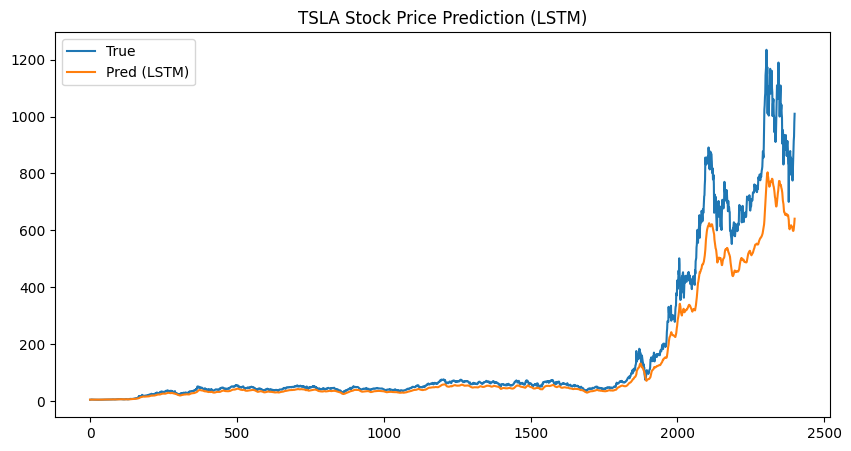

In [49]:
# 4-5. LSTM 예측 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(original_y_test_lstm, label='True')
plt.plot(original_predictions_lstm, label='Pred (LSTM)')
plt.legend()
plt.title("TSLA Stock Price Prediction (LSTM)")
plt.show()